In [1]:
import pandas as pd
import numpy as np
import sqlite3
import pathlib
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from scipy import stats

# Configura o caminho para o banco de dados
project_root = pathlib.Path("..") 
db_path = project_root / "banco de dados" / "crash_bot_historico.db"

print(f"Carregando dados de: {db_path}")

with sqlite3.connect(db_path) as conn:
    query = "SELECT timestamp, multiplicador FROM multiplicadores_historico ORDER BY timestamp ASC"
    df = pd.read_sql_query(query, conn, parse_dates=["timestamp"])

df = df.reset_index(drop=True)
multiplicadores = df['multiplicador'].values
print(f"✅ {len(multiplicadores):,} rodadas carregadas.")

# Criar coluna de baixa
df['baixa'] = (df['multiplicador'] < 2.0).astype(int)
print(f"\nBaixas (<2.0x): {df['baixa'].sum():,} ({df['baixa'].mean()*100:.1f}%)")

Carregando dados de: ..\banco de dados\crash_bot_historico.db
✅ 105,281 rodadas carregadas.

Baixas (<2.0x): 57,323 (54.4%)


In [2]:
# --- CÉLULA 2: IDENTIFICAR TODAS AS SEQUÊNCIAS DE BAIXAS ---

print("="*80)
print("🔍 IDENTIFICANDO SEQUÊNCIAS DE BAIXAS E QUEBRAS")
print("="*80)

def encontrar_sequencias_baixas(mult, limite_baixa=2.0):
    """Encontra todas as sequências de baixas consecutivas."""
    sequencias = []
    i = 0
    
    while i < len(mult):
        if mult[i] < limite_baixa:
            inicio = i
            tamanho = 0
            valores = []
            
            while i < len(mult) and mult[i] < limite_baixa:
                valores.append(mult[i])
                tamanho += 1
                i += 1
            
            # Pegar o valor que quebrou a sequência (alta)
            valor_quebra = mult[i] if i < len(mult) else None
            
            sequencias.append({
                'inicio': inicio,
                'fim': i - 1,
                'tamanho': tamanho,
                'valores': valores,
                'media': np.mean(valores),
                'min': np.min(valores),
                'max': np.max(valores),
                'valor_quebra': valor_quebra
            })
        else:
            i += 1
    
    return sequencias

sequencias = encontrar_sequencias_baixas(multiplicadores)
print(f"\nTotal de sequências de baixas: {len(sequencias):,}")

# Separar por tamanho
seq_por_tamanho = {}
for s in sequencias:
    t = s['tamanho']
    if t not in seq_por_tamanho:
        seq_por_tamanho[t] = []
    seq_por_tamanho[t].append(s)

print(f"\nDistribuição:")
for t in sorted(seq_por_tamanho.keys()):
    qtd = len(seq_por_tamanho[t])
    relevancia = ""
    if t >= 6: relevancia = "← GATILHO"
    if t >= 9: relevancia = "← CICLO 2"
    if t >= 12: relevancia = "← 💀 QUEBRA!"
    print(f"  {t:2d} baixas: {qtd:5,} sequências {relevancia}")

🔍 IDENTIFICANDO SEQUÊNCIAS DE BAIXAS E QUEBRAS

Total de sequências de baixas: 26,157

Distribuição:
   1 baixas: 11,746 sequências 
   2 baixas: 6,595 sequências 
   3 baixas: 3,550 sequências 
   4 baixas: 1,926 sequências 
   5 baixas: 1,069 sequências 
   6 baixas:   679 sequências ← GATILHO
   7 baixas:   318 sequências ← GATILHO
   8 baixas:   153 sequências ← GATILHO
   9 baixas:    71 sequências ← CICLO 2
  10 baixas:    31 sequências ← CICLO 2
  11 baixas:    13 sequências ← CICLO 2
  12 baixas:     6 sequências ← 💀 QUEBRA!


In [3]:
# --- CÉLULA 3: ANÁLISE DETALHADA DAS QUEBRAS (12+ BAIXAS) ---

print("\n" + "="*80)
print("💀 ANÁLISE DETALHADA DAS QUEBRAS (12+ BAIXAS)")
print("="*80)

quebras = [s for s in sequencias if s['tamanho'] >= 12]
print(f"\nTotal de quebras: {len(quebras)}")

for i, q in enumerate(quebras, 1):
    print(f"\n{'─'*60}")
    print(f"💀 QUEBRA #{i}")
    print(f"{'─'*60}")
    print(f"   Posição: rodada {q['inicio']:,} até {q['fim']:,}")
    print(f"   Tamanho: {q['tamanho']} baixas consecutivas")
    print(f"   Timestamp: {df.iloc[q['inicio']]['timestamp']}")
    print(f"   Valores da sequência:")
    for j, v in enumerate(q['valores'], 1):
        marcador = "🎯" if j == 7 else "  "  # Marca onde seria a entrada (dobra 1)
        print(f"      {marcador} Baixa {j:2d}: {v:.2f}x")
    print(f"   Valor que quebrou: {q['valor_quebra']:.2f}x" if q['valor_quebra'] else "   [fim dos dados]")
    print(f"   Média das baixas: {q['media']:.2f}x")
    print(f"   Mínimo: {q['min']:.2f}x | Máximo: {q['max']:.2f}x")


💀 ANÁLISE DETALHADA DAS QUEBRAS (12+ BAIXAS)

Total de quebras: 6

────────────────────────────────────────────────────────────
💀 QUEBRA #1
────────────────────────────────────────────────────────────
   Posição: rodada 22,197 até 22,208
   Tamanho: 12 baixas consecutivas
   Timestamp: 2025-12-07 20:27:28.953132
   Valores da sequência:
         Baixa  1: 1.76x
         Baixa  2: 1.84x
         Baixa  3: 1.12x
         Baixa  4: 1.76x
         Baixa  5: 1.98x
         Baixa  6: 1.24x
      🎯 Baixa  7: 1.44x
         Baixa  8: 1.12x
         Baixa  9: 1.09x
         Baixa 10: 1.53x
         Baixa 11: 1.04x
         Baixa 12: 1.27x
   Valor que quebrou: 2.49x
   Média das baixas: 1.43x
   Mínimo: 1.04x | Máximo: 1.98x

────────────────────────────────────────────────────────────
💀 QUEBRA #2
────────────────────────────────────────────────────────────
   Posição: rodada 24,513 até 24,524
   Tamanho: 12 baixas consecutivas
   Timestamp: 2025-12-08 13:33:16.948413
   Valores da sequência:


In [4]:
# --- CÉLULA 4: CONTEXTO ANTES DAS QUEBRAS (250 RODADAS) ---

print("\n" + "="*80)
print("🔬 ANÁLISE DO CONTEXTO ANTES DAS QUEBRAS (250 RODADAS)")
print("="*80)

JANELA = 250  # Mesmo tamanho usado pela ML!

contextos_quebras = []

for i, q in enumerate(quebras, 1):
    inicio_janela = max(0, q['inicio'] - JANELA)
    fim_janela = q['inicio']
    
    if fim_janela - inicio_janela < 50:  # Precisa de pelo menos 50 rodadas
        continue
    
    janela = multiplicadores[inicio_janela:fim_janela]
    
    # Métricas da janela
    pct_baixas = np.sum(janela < 2.0) / len(janela) * 100
    media = np.mean(janela)
    mediana = np.median(janela)
    std = np.std(janela)
    
    # Sequências longas na janela
    seq_6plus = 0
    seq_atual = 0
    for v in janela:
        if v < 2.0:
            seq_atual += 1
        else:
            if seq_atual >= 6:
                seq_6plus += 1
            seq_atual = 0
    
    # Tendência (regressão linear)
    x = np.arange(len(janela))
    slope, intercept, r_value, p_value, std_err = stats.linregress(x, janela)
    
    # Últimas 50 rodadas vs primeiras 50
    primeiras_50 = janela[:50]
    ultimas_50 = janela[-50:]
    pct_baixas_inicio = np.sum(primeiras_50 < 2.0) / 50 * 100
    pct_baixas_fim = np.sum(ultimas_50 < 2.0) / 50 * 100
    
    contexto = {
        'quebra_num': i,
        'posicao': q['inicio'],
        'tamanho_quebra': q['tamanho'],
        'pct_baixas': pct_baixas,
        'media': media,
        'mediana': mediana,
        'std': std,
        'seq_6plus': seq_6plus,
        'slope': slope,
        'pct_baixas_inicio': pct_baixas_inicio,
        'pct_baixas_fim': pct_baixas_fim,
        'aumento_baixas': pct_baixas_fim - pct_baixas_inicio
    }
    contextos_quebras.append(contexto)
    
    print(f"\n{'─'*60}")
    print(f"💀 QUEBRA #{i} - Contexto das {len(janela)} rodadas anteriores")
    print(f"{'─'*60}")
    print(f"   📊 % Baixas na janela: {pct_baixas:.1f}%")
    print(f"   📊 Média: {media:.2f}x | Mediana: {mediana:.2f}x")
    print(f"   📊 Desvio Padrão: {std:.2f}")
    print(f"   📊 Sequências 6+ na janela: {seq_6plus}")
    print(f"   📈 Tendência (slope): {slope:.4f} ({'📉 QUEDA' if slope < 0 else '📈 SUBIDA'})")
    print(f"   📊 % Baixas início (50 rod): {pct_baixas_inicio:.1f}%")
    print(f"   📊 % Baixas fim (50 rod): {pct_baixas_fim:.1f}%")
    print(f"   {'⚠️ AUMENTO' if pct_baixas_fim > pct_baixas_inicio else '✅ DIMINUIÇÃO'}: {abs(pct_baixas_fim - pct_baixas_inicio):.1f}%")


🔬 ANÁLISE DO CONTEXTO ANTES DAS QUEBRAS (250 RODADAS)

────────────────────────────────────────────────────────────
💀 QUEBRA #1 - Contexto das 250 rodadas anteriores
────────────────────────────────────────────────────────────
   📊 % Baixas na janela: 53.6%
   📊 Média: 6.68x | Mediana: 1.91x
   📊 Desvio Padrão: 18.64
   📊 Sequências 6+ na janela: 2
   📈 Tendência (slope): 0.0106 (📈 SUBIDA)
   📊 % Baixas início (50 rod): 50.0%
   📊 % Baixas fim (50 rod): 58.0%
   ⚠️ AUMENTO: 8.0%

────────────────────────────────────────────────────────────
💀 QUEBRA #2 - Contexto das 250 rodadas anteriores
────────────────────────────────────────────────────────────
   📊 % Baixas na janela: 53.6%
   📊 Média: 6.09x | Mediana: 1.90x
   📊 Desvio Padrão: 18.62
   📊 Sequências 6+ na janela: 2
   📈 Tendência (slope): -0.0301 (📉 QUEDA)
   📊 % Baixas início (50 rod): 52.0%
   📊 % Baixas fim (50 rod): 52.0%
   ✅ DIMINUIÇÃO: 0.0%

────────────────────────────────────────────────────────────
💀 QUEBRA #3 - Context

In [5]:
# --- CÉLULA 5: COMPARAR CONTEXTO DAS QUEBRAS vs CONTEXTO NORMAL ---

print("\n" + "="*80)
print("📊 COMPARAÇÃO: CONTEXTO QUEBRAS vs CONTEXTO NORMAL")
print("="*80)

# Calcular métricas para janelas NORMAIS (onde NÃO houve quebra)
# Vamos amostrar 100 janelas aleatórias

np.random.seed(42)
posicoes_quebras = [q['inicio'] for q in quebras]

contextos_normais = []
tentativas = 0

while len(contextos_normais) < 100 and tentativas < 1000:
    tentativas += 1
    pos = np.random.randint(JANELA, len(multiplicadores) - 20)
    
    # Verificar se não está perto de uma quebra
    perto_quebra = any(abs(pos - pq) < 300 for pq in posicoes_quebras)
    if perto_quebra:
        continue
    
    janela = multiplicadores[pos - JANELA:pos]
    
    pct_baixas = np.sum(janela < 2.0) / len(janela) * 100
    media = np.mean(janela)
    std = np.std(janela)
    
    # Sequências longas
    seq_6plus = 0
    seq_atual = 0
    for v in janela:
        if v < 2.0:
            seq_atual += 1
        else:
            if seq_atual >= 6:
                seq_6plus += 1
            seq_atual = 0
    
    # Tendência
    x = np.arange(len(janela))
    slope, _, _, _, _ = stats.linregress(x, janela)
    
    # Início vs Fim
    pct_baixas_inicio = np.sum(janela[:50] < 2.0) / 50 * 100
    pct_baixas_fim = np.sum(janela[-50:] < 2.0) / 50 * 100
    
    contextos_normais.append({
        'pct_baixas': pct_baixas,
        'media': media,
        'std': std,
        'seq_6plus': seq_6plus,
        'slope': slope,
        'pct_baixas_inicio': pct_baixas_inicio,
        'pct_baixas_fim': pct_baixas_fim,
        'aumento_baixas': pct_baixas_fim - pct_baixas_inicio
    })

print(f"\nAmostras coletadas: {len(contextos_normais)} contextos normais")

# Comparar estatísticas
df_quebras = pd.DataFrame(contextos_quebras)
df_normais = pd.DataFrame(contextos_normais)

print(f"\n{'─'*70}")
print(f"{'MÉTRICA':<30} {'ANTES QUEBRA':>18} {'NORMAL':>18} {'DIFERENÇA':>12}")
print(f"{'─'*70}")

metricas = ['pct_baixas', 'media', 'std', 'seq_6plus', 'slope', 'aumento_baixas']
nomes = ['% Baixas', 'Média Mult.', 'Desvio Padrão', 'Seq. 6+ baixas', 'Tendência (slope)', 'Δ Baixas (fim-início)']

for metrica, nome in zip(metricas, nomes):
    media_quebra = df_quebras[metrica].mean()
    media_normal = df_normais[metrica].mean()
    diff = media_quebra - media_normal
    
    # Teste estatístico
    if len(df_quebras) >= 3:
        t_stat, p_value = stats.ttest_ind(df_quebras[metrica], df_normais[metrica])
        sig = "⚠️" if p_value < 0.1 else "  "
    else:
        sig = "  "
    
    print(f"{nome:<30} {media_quebra:>18.2f} {media_normal:>18.2f} {diff:>+12.2f} {sig}")

print(f"{'─'*70}")
print(f"\n⚠️ = diferença possivelmente significativa (p < 0.1)")


📊 COMPARAÇÃO: CONTEXTO QUEBRAS vs CONTEXTO NORMAL

Amostras coletadas: 100 contextos normais

──────────────────────────────────────────────────────────────────────
MÉTRICA                              ANTES QUEBRA             NORMAL    DIFERENÇA
──────────────────────────────────────────────────────────────────────
% Baixas                                    54.00              54.28        -0.28   
Média Mult.                                  7.16               6.07        +1.10 ⚠️
Desvio Padrão                               22.61              18.91        +3.70   
Seq. 6+ baixas                               1.50               3.04        -1.54 ⚠️
Tendência (slope)                           -0.01               0.00        -0.01 ⚠️
Δ Baixas (fim-início)                       -1.67               1.40        -3.07   
──────────────────────────────────────────────────────────────────────

⚠️ = diferença possivelmente significativa (p < 0.1)


In [6]:
# --- CÉLULA 6: ANÁLISE DE FASE ARRECADATÓRIA ---

print("\n" + "="*80)
print("💰 ANÁLISE DE FASE ARRECADATÓRIA (PADRÕES ANTES DAS QUEBRAS)")
print("="*80)

# Calcular % de baixas em janelas deslizantes de 50 rodadas
JANELA_CURTA = 50

pct_baixas_rolling = []
for i in range(JANELA_CURTA, len(multiplicadores)):
    janela = multiplicadores[i-JANELA_CURTA:i]
    pct = np.sum(janela < 2.0) / JANELA_CURTA * 100
    pct_baixas_rolling.append(pct)

pct_baixas_rolling = np.array(pct_baixas_rolling)

print(f"\n📊 Estatísticas do % de Baixas (janela de {JANELA_CURTA} rodadas):")
print(f"   Média: {np.mean(pct_baixas_rolling):.1f}%")
print(f"   Desvio Padrão: {np.std(pct_baixas_rolling):.1f}%")
print(f"   Mínimo: {np.min(pct_baixas_rolling):.1f}%")
print(f"   Máximo: {np.max(pct_baixas_rolling):.1f}%")

# Definir limiar para "fase arrecadatória"
limiar_alto = np.mean(pct_baixas_rolling) + np.std(pct_baixas_rolling)
print(f"\n⚠️ Limiar de ALERTA (média + 1 std): {limiar_alto:.1f}%")

# Verificar se as quebras ocorreram em momentos de alta % de baixas
print(f"\n{'─'*60}")
print(f"💀 % de Baixas no momento de cada QUEBRA:")
print(f"{'─'*60}")

pcts_antes_quebras = []
for i, q in enumerate(quebras, 1):
    pos = q['inicio'] - JANELA_CURTA
    if pos >= 0 and pos < len(pct_baixas_rolling):
        pct = pct_baixas_rolling[pos]
        pcts_antes_quebras.append(pct)
        alerta = "🚨 ACIMA DO LIMIAR!" if pct > limiar_alto else ""
        print(f"   Quebra #{i}: {pct:.1f}% de baixas {alerta}")

print(f"\n📊 Média do % baixas ANTES das quebras: {np.mean(pcts_antes_quebras):.1f}%")
print(f"📊 Média do % baixas GERAL: {np.mean(pct_baixas_rolling):.1f}%")
print(f"📊 Diferença: {np.mean(pcts_antes_quebras) - np.mean(pct_baixas_rolling):+.1f}%")


💰 ANÁLISE DE FASE ARRECADATÓRIA (PADRÕES ANTES DAS QUEBRAS)

📊 Estatísticas do % de Baixas (janela de 50 rodadas):
   Média: 54.4%
   Desvio Padrão: 6.8%
   Mínimo: 28.0%
   Máximo: 80.0%

⚠️ Limiar de ALERTA (média + 1 std): 61.3%

────────────────────────────────────────────────────────────
💀 % de Baixas no momento de cada QUEBRA:
────────────────────────────────────────────────────────────
   Quebra #1: 58.0% de baixas 
   Quebra #2: 52.0% de baixas 
   Quebra #3: 56.0% de baixas 
   Quebra #4: 44.0% de baixas 
   Quebra #5: 62.0% de baixas 🚨 ACIMA DO LIMIAR!
   Quebra #6: 50.0% de baixas 

📊 Média do % baixas ANTES das quebras: 53.7%
📊 Média do % baixas GERAL: 54.4%
📊 Diferença: -0.8%


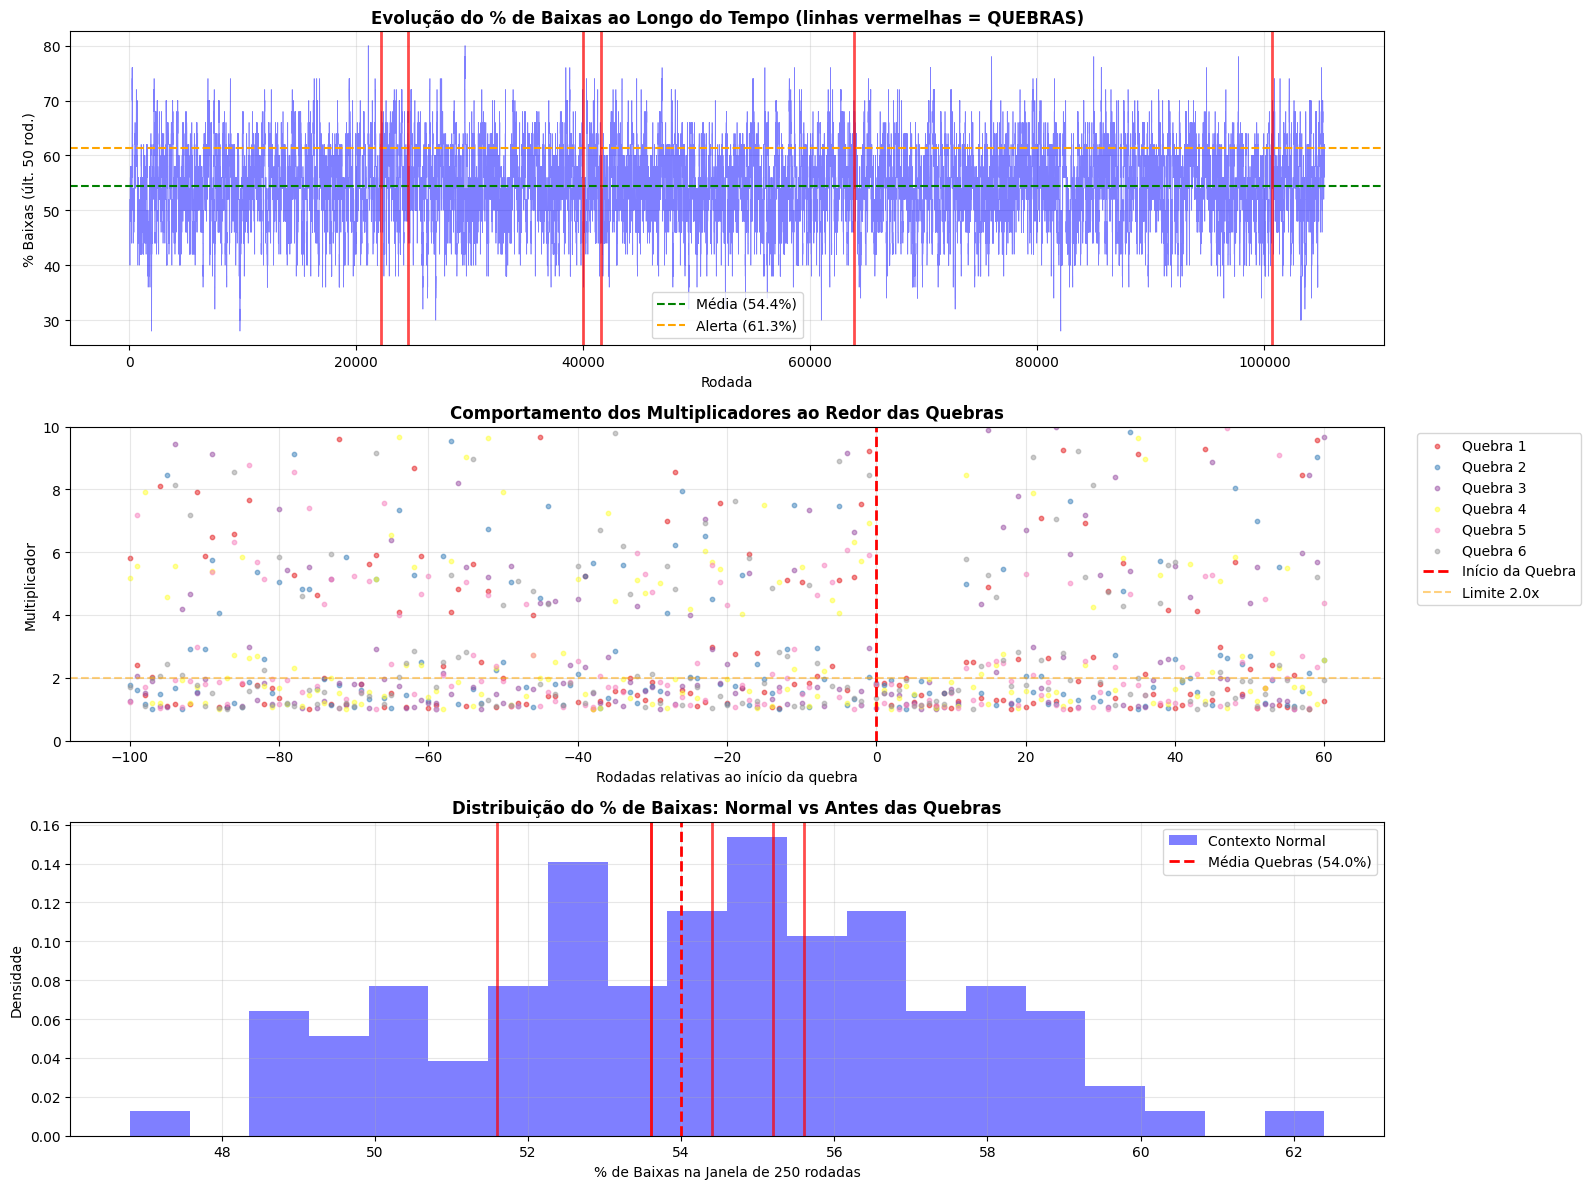


📁 Gráfico salvo: 01_analise_fases_quebras.png


In [7]:
# --- CÉLULA 7: VISUALIZAÇÃO DAS QUEBRAS NO TEMPO ---

fig, axes = plt.subplots(3, 1, figsize=(16, 12))

# 1. Evolução do % de baixas com marcação das quebras
ax1 = axes[0]
x_range = range(JANELA_CURTA, len(multiplicadores))
ax1.plot(x_range, pct_baixas_rolling, color='blue', alpha=0.5, linewidth=0.5)
ax1.axhline(y=np.mean(pct_baixas_rolling), color='green', linestyle='--', label=f'Média ({np.mean(pct_baixas_rolling):.1f}%)')
ax1.axhline(y=limiar_alto, color='orange', linestyle='--', label=f'Alerta ({limiar_alto:.1f}%)')

# Marcar quebras
for q in quebras:
    ax1.axvline(x=q['inicio'], color='red', alpha=0.7, linewidth=2)

ax1.set_xlabel('Rodada')
ax1.set_ylabel('% Baixas (últ. 50 rod.)')
ax1.set_title('Evolução do % de Baixas ao Longo do Tempo (linhas vermelhas = QUEBRAS)', fontweight='bold')
ax1.legend()
ax1.grid(True, alpha=0.3)

# 2. Zoom nas quebras (100 rodadas antes e depois)
ax2 = axes[1]
cores = plt.cm.Set1(np.linspace(0, 1, len(quebras)))

for idx, q in enumerate(quebras):
    inicio = max(0, q['inicio'] - 100)
    fim = min(len(multiplicadores), q['fim'] + 50)
    
    # Normalizar para x = 0 ser o início da quebra
    x_rel = np.arange(inicio - q['inicio'], fim - q['inicio'])
    y_vals = multiplicadores[inicio:fim]
    
    ax2.scatter(x_rel, y_vals, alpha=0.5, s=10, color=cores[idx], label=f"Quebra {idx+1}")

ax2.axvline(x=0, color='red', linestyle='--', linewidth=2, label='Início da Quebra')
ax2.axhline(y=2.0, color='orange', linestyle='--', alpha=0.5, label='Limite 2.0x')
ax2.set_xlabel('Rodadas relativas ao início da quebra')
ax2.set_ylabel('Multiplicador')
ax2.set_title('Comportamento dos Multiplicadores ao Redor das Quebras', fontweight='bold')
ax2.legend(bbox_to_anchor=(1.02, 1), loc='upper left')
ax2.set_ylim(0, 10)
ax2.grid(True, alpha=0.3)

# 3. Histograma comparativo
ax3 = axes[2]
ax3.hist(df_normais['pct_baixas'], bins=20, alpha=0.5, label='Contexto Normal', color='blue', density=True)
if len(df_quebras) > 0:
    for pct in df_quebras['pct_baixas']:
        ax3.axvline(x=pct, color='red', linewidth=2, alpha=0.7)
ax3.axvline(x=df_quebras['pct_baixas'].mean(), color='red', linestyle='--', linewidth=2, label=f"Média Quebras ({df_quebras['pct_baixas'].mean():.1f}%)")
ax3.set_xlabel('% de Baixas na Janela de 250 rodadas')
ax3.set_ylabel('Densidade')
ax3.set_title('Distribuição do % de Baixas: Normal vs Antes das Quebras', fontweight='bold')
ax3.legend()
ax3.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('01_analise_fases_quebras.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n📁 Gráfico salvo: 01_analise_fases_quebras.png")

In [8]:
# --- CÉLULA 8: ANÁLISE DE PADRÕES SEQUENCIAIS ANTES DAS QUEBRAS ---

print("\n" + "="*80)
print("🔬 ANÁLISE DE PADRÕES SEQUENCIAIS ANTES DAS QUEBRAS")
print("="*80)

print("\nAnalisando as últimas 20 rodadas ANTES de cada quebra iniciar...")

for i, q in enumerate(quebras, 1):
    inicio = q['inicio']
    
    if inicio < 20:
        continue
    
    # Últimas 20 rodadas antes da quebra começar
    pre_quebra = multiplicadores[inicio-20:inicio]
    
    print(f"\n{'─'*60}")
    print(f"💀 QUEBRA #{i} - 20 rodadas ANTES:")
    print(f"{'─'*60}")
    
    baixas = sum(1 for v in pre_quebra if v < 2.0)
    print(f"   Baixas: {baixas}/20 ({baixas/20*100:.0f}%)")
    print(f"   Média: {np.mean(pre_quebra):.2f}x")
    
    # Contar sequências de baixas
    seq_atual = 0
    seqs = []
    for v in pre_quebra:
        if v < 2.0:
            seq_atual += 1
        else:
            if seq_atual > 0:
                seqs.append(seq_atual)
            seq_atual = 0
    if seq_atual > 0:
        seqs.append(seq_atual)
    
    print(f"   Sequências de baixas: {seqs}")
    print(f"   Maior sequência: {max(seqs) if seqs else 0}")
    
    # Mostrar os valores
    print(f"   Valores: ", end="")
    for v in pre_quebra:
        cor = "🔴" if v < 2.0 else "🟢"
        print(f"{cor}{v:.1f} ", end="")
    print()


🔬 ANÁLISE DE PADRÕES SEQUENCIAIS ANTES DAS QUEBRAS

Analisando as últimas 20 rodadas ANTES de cada quebra iniciar...

────────────────────────────────────────────────────────────
💀 QUEBRA #1 - 20 rodadas ANTES:
────────────────────────────────────────────────────────────
   Baixas: 8/20 (40%)
   Média: 11.83x
   Sequências de baixas: [1, 1, 3, 1, 1, 1]
   Maior sequência: 3
   Valores: 🔴1.2 🟢2.8 🔴1.7 🟢5.9 🟢2.8 🔴1.6 🔴1.1 🔴1.0 🟢5.1 🔴1.8 🟢5.1 🔴1.8 🟢2.1 🟢171.6 🟢2.4 🟢5.1 🔴1.6 🟢5.2 🟢7.5 🟢9.2 

────────────────────────────────────────────────────────────
💀 QUEBRA #2 - 20 rodadas ANTES:
────────────────────────────────────────────────────────────
   Baixas: 12/20 (60%)
   Média: 3.65x
   Sequências de baixas: [2, 1, 3, 2, 1, 3]
   Maior sequência: 3
   Valores: 🔴1.1 🔴1.7 🟢5.3 🔴1.1 🟢2.4 🔴1.9 🔴1.5 🔴1.0 🟢2.9 🟢7.5 🔴1.5 🔴1.1 🟢3.0 🔴2.0 🟢25.8 🟢7.5 🔴1.1 🔴1.3 🔴1.1 🟢2.0 

────────────────────────────────────────────────────────────
💀 QUEBRA #3 - 20 rodadas ANTES:
───────────────────────────────────────

In [9]:
# --- CÉLULA 9: DETECTAR "FASES" NO JOGO ---

print("\n" + "="*80)
print("🎰 DETECÇÃO DE FASES NO JOGO")
print("="*80)

# Definir fases baseado no % de baixas
media_geral = np.mean(pct_baixas_rolling)
std_geral = np.std(pct_baixas_rolling)

FASE_NORMAL_MIN = media_geral - std_geral
FASE_NORMAL_MAX = media_geral + std_geral

print(f"\n📊 Definição das Fases (baseado em % de baixas):")
print(f"   🟢 FASE FAVORÁVEL (liberação): < {FASE_NORMAL_MIN:.1f}%")
print(f"   ⚪ FASE NORMAL: {FASE_NORMAL_MIN:.1f}% - {FASE_NORMAL_MAX:.1f}%")
print(f"   🔴 FASE ARRECADATÓRIA: > {FASE_NORMAL_MAX:.1f}%")

# Classificar cada momento
fases = []
for pct in pct_baixas_rolling:
    if pct < FASE_NORMAL_MIN:
        fases.append('FAVORAVEL')
    elif pct > FASE_NORMAL_MAX:
        fases.append('ARRECADATORIA')
    else:
        fases.append('NORMAL')

fases = np.array(fases)

print(f"\n📊 Distribuição das Fases:")
for fase in ['FAVORAVEL', 'NORMAL', 'ARRECADATORIA']:
    qtd = np.sum(fases == fase)
    pct = qtd / len(fases) * 100
    emoji = '🟢' if fase == 'FAVORAVEL' else ('🔴' if fase == 'ARRECADATORIA' else '⚪')
    print(f"   {emoji} {fase}: {qtd:,} rodadas ({pct:.1f}%)")

# Verificar em qual fase cada quebra ocorreu
print(f"\n{'─'*60}")
print(f"💀 FASE NO MOMENTO DE CADA QUEBRA:")
print(f"{'─'*60}")

fases_quebras = []
for i, q in enumerate(quebras, 1):
    pos = q['inicio'] - JANELA_CURTA
    if 0 <= pos < len(fases):
        fase = fases[pos]
        fases_quebras.append(fase)
        emoji = '🟢' if fase == 'FAVORAVEL' else ('🔴' if fase == 'ARRECADATORIA' else '⚪')
        print(f"   Quebra #{i}: {emoji} {fase}")

print(f"\n📊 Resumo:")
for fase in ['FAVORAVEL', 'NORMAL', 'ARRECADATORIA']:
    qtd = fases_quebras.count(fase)
    print(f"   {fase}: {qtd}/{len(fases_quebras)} quebras")


🎰 DETECÇÃO DE FASES NO JOGO

📊 Definição das Fases (baseado em % de baixas):
   🟢 FASE FAVORÁVEL (liberação): < 47.6%
   ⚪ FASE NORMAL: 47.6% - 61.3%
   🔴 FASE ARRECADATÓRIA: > 61.3%

📊 Distribuição das Fases:
   🟢 FAVORAVEL: 15,008 rodadas (14.3%)
   ⚪ NORMAL: 72,443 rodadas (68.8%)
   🔴 ARRECADATORIA: 17,780 rodadas (16.9%)

────────────────────────────────────────────────────────────
💀 FASE NO MOMENTO DE CADA QUEBRA:
────────────────────────────────────────────────────────────
   Quebra #1: ⚪ NORMAL
   Quebra #2: ⚪ NORMAL
   Quebra #3: ⚪ NORMAL
   Quebra #4: 🟢 FAVORAVEL
   Quebra #5: 🔴 ARRECADATORIA
   Quebra #6: ⚪ NORMAL

📊 Resumo:
   FAVORAVEL: 1/6 quebras
   NORMAL: 4/6 quebras
   ARRECADATORIA: 1/6 quebras


In [10]:
# --- CÉLULA 10: ANÁLISE DE RISCO POR FASE ---

print("\n" + "="*80)
print("📊 RISCO DE QUEBRA POR FASE")
print("="*80)

# Contar quantas entradas e quebras em cada fase
# Simular a estratégia com detecção de fase

entradas_por_fase = {'FAVORAVEL': 0, 'NORMAL': 0, 'ARRECADATORIA': 0}
quebras_por_fase = {'FAVORAVEL': 0, 'NORMAL': 0, 'ARRECADATORIA': 0}

GATILHO = 6

i = 0
while i < len(multiplicadores):
    # Contar baixas
    lows = 0
    j = i
    while j < len(multiplicadores) and multiplicadores[j] < 2.0:
        lows += 1
        j += 1
    
    if lows >= GATILHO:
        # Determinar fase atual
        pos_fase = i - JANELA_CURTA
        if 0 <= pos_fase < len(fases):
            fase = fases[pos_fase]
        else:
            fase = 'NORMAL'
        
        entradas_por_fase[fase] += 1
        
        if lows >= 12:  # Quebra
            quebras_por_fase[fase] += 1
    
    i = j if j > i else i + 1

print(f"\n{'FASE':<20} {'ENTRADAS':>12} {'QUEBRAS':>12} {'TAXA QUEBRA':>15} {'RISCO':>10}")
print(f"{'─'*70}")

for fase in ['FAVORAVEL', 'NORMAL', 'ARRECADATORIA']:
    entradas = entradas_por_fase[fase]
    quebras_f = quebras_por_fase[fase]
    taxa = quebras_f / entradas * 100 if entradas > 0 else 0
    
    risco = '🟢 BAIXO' if taxa < 0.3 else ('🟡 MÉDIO' if taxa < 1 else '🔴 ALTO')
    
    print(f"{fase:<20} {entradas:>12,} {quebras_f:>12} {taxa:>14.2f}% {risco:>10}")

print(f"{'─'*70}")
print(f"{'TOTAL':<20} {sum(entradas_por_fase.values()):>12,} {sum(quebras_por_fase.values()):>12}")


📊 RISCO DE QUEBRA POR FASE

FASE                     ENTRADAS      QUEBRAS     TAXA QUEBRA      RISCO
──────────────────────────────────────────────────────────────────────
FAVORAVEL                     240            1           0.42%    🟡 MÉDIO
NORMAL                        868            4           0.46%    🟡 MÉDIO
ARRECADATORIA                 163            1           0.61%    🟡 MÉDIO
──────────────────────────────────────────────────────────────────────
TOTAL                       1,271            6


In [11]:
# --- CÉLULA 11: SIMULAÇÃO COM DETECTOR DE FASE ---

print("\n" + "="*80)
print("🧪 SIMULAÇÃO: COM vs SEM DETECTOR DE FASE")
print("="*80)

def simular_com_detector_fase(mult, fases_arr, banca=500, gatilho=6, target=1.99, 
                               evitar_arrecadatoria=False, evitar_threshold=None):
    """
    Simula a estratégia 1-2-4-1-2-4 com opção de evitar fases arrecadatórias.
    """
    parte = (banca / 2) / 7
    dobras = {1: parte*1, 2: parte*2, 3: parte*4, 4: parte*1, 5: parte*2, 6: parte*4}
    
    lucro = 0
    quebras_total = 0
    entradas = 0
    entradas_evitadas = 0
    quebras_evitadas = 0
    historico = [0]
    
    i = 0
    while i < len(mult):
        lows = 0
        j = i
        while j < len(mult) and mult[j] < 2.0:
            lows += 1
            j += 1
        
        if lows >= gatilho:
            # Determinar fase
            pos_fase = i - JANELA_CURTA
            if 0 <= pos_fase < len(fases_arr):
                fase = fases_arr[pos_fase]
                pct_atual = pct_baixas_rolling[pos_fase] if pos_fase < len(pct_baixas_rolling) else 54
            else:
                fase = 'NORMAL'
                pct_atual = 54
            
            # Decidir se entra
            deve_evitar = False
            if evitar_arrecadatoria and fase == 'ARRECADATORIA':
                deve_evitar = True
            if evitar_threshold and pct_atual > evitar_threshold:
                deve_evitar = True
            
            seria_quebra = lows >= 12
            
            if deve_evitar:
                entradas_evitadas += 1
                if seria_quebra:
                    quebras_evitadas += 1
            else:
                entradas += 1
                entrada_pos = i + gatilho
                perdas = 0
                ganhou = False
                
                for d in range(1, 7):
                    pos = entrada_pos + (d - 1)
                    if pos >= len(mult):
                        break
                    if mult[pos] >= target:
                        ganho = dobras[d] * (target - 1) * 0.99 - perdas
                        lucro += ganho
                        ganhou = True
                        break
                    else:
                        perdas += dobras[d]
                
                if not ganhou:
                    lucro -= banca
                    quebras_total += 1
                
                historico.append(lucro)
        
        i = j if j > i else i + 1
    
    return {
        'lucro': lucro,
        'quebras': quebras_total,
        'entradas': entradas,
        'entradas_evitadas': entradas_evitadas,
        'quebras_evitadas': quebras_evitadas,
        'historico': historico
    }

# Simular sem detector
res_sem = simular_com_detector_fase(multiplicadores, fases, evitar_arrecadatoria=False)

# Simular com detector de fase
res_com_fase = simular_com_detector_fase(multiplicadores, fases, evitar_arrecadatoria=True)

# Simular com threshold de 60%
res_com_60 = simular_com_detector_fase(multiplicadores, fases, evitar_threshold=60)

# Simular com threshold de 58%
res_com_58 = simular_com_detector_fase(multiplicadores, fases, evitar_threshold=58)

print(f"\n{'ESTRATÉGIA':<35} {'ENTRADAS':>10} {'EVITADAS':>10} {'QUEBRAS':>10} {'EVIT.':>8} {'LUCRO':>15}")
print(f"{'─'*95}")

resultados_detector = [
    ('Sem Detector (Original)', res_sem),
    ('Evitar Fase Arrecadatória', res_com_fase),
    ('Evitar se % baixas > 60%', res_com_60),
    ('Evitar se % baixas > 58%', res_com_58),
]

for nome, res in resultados_detector:
    print(f"{nome:<35} {res['entradas']:>10,} {res['entradas_evitadas']:>10,} {res['quebras']:>10} {res['quebras_evitadas']:>8} R$ {res['lucro']:>12,.2f}")


🧪 SIMULAÇÃO: COM vs SEM DETECTOR DE FASE

ESTRATÉGIA                            ENTRADAS   EVITADAS    QUEBRAS    EVIT.           LUCRO
───────────────────────────────────────────────────────────────────────────────────────────────
Sem Detector (Original)                  1,271          0          6        0 R$    12,676.12
Evitar Fase Arrecadatória                1,108        163          5        1 R$    11,832.30
Evitar se % baixas > 60%                 1,108        163          5        1 R$    11,832.30
Evitar se % baixas > 58%                 1,012        259          5        1 R$    10,017.44


In [12]:
# --- CÉLULA 12: CONCLUSÃO ---

print("\n" + "="*80)
print("🏆 CONCLUSÃO DA ANÁLISE DE FASES")
print("="*80)

print(f"""
📊 RESUMO DOS ACHADOS:

1. EXISTÊNCIA DE FASES:
   {'✅ SIM' if np.std(pct_baixas_rolling) > 5 else '❌ NÃO'} - O jogo apresenta variação significativa no % de baixas
   • Variação: {np.min(pct_baixas_rolling):.1f}% a {np.max(pct_baixas_rolling):.1f}%
   • Desvio padrão: {np.std(pct_baixas_rolling):.1f}%

2. CORRELAÇÃO FASE x QUEBRA:
   • Quebras em fase FAVORÁVEL: {fases_quebras.count('FAVORAVEL')}/{len(fases_quebras)}
   • Quebras em fase NORMAL: {fases_quebras.count('NORMAL')}/{len(fases_quebras)}
   • Quebras em fase ARRECADATÓRIA: {fases_quebras.count('ARRECADATORIA')}/{len(fases_quebras)}

3. EFICÁCIA DO DETECTOR:
   • Original: {res_sem['quebras']} quebras, R$ {res_sem['lucro']:,.2f}
   • Com detector fase: {res_com_fase['quebras']} quebras ({res_com_fase['quebras_evitadas']} evitadas), R$ {res_com_fase['lucro']:,.2f}
   • Com threshold 60%: {res_com_60['quebras']} quebras ({res_com_60['quebras_evitadas']} evitadas), R$ {res_com_60['lucro']:,.2f}

4. CONTEXTO ANTES DAS QUEBRAS:
   • % baixas médio ANTES das quebras: {np.mean(pcts_antes_quebras):.1f}%
   • % baixas médio GERAL: {np.mean(pct_baixas_rolling):.1f}%
   • Diferença: {np.mean(pcts_antes_quebras) - np.mean(pct_baixas_rolling):+.1f}%
""")

# Determinar se o detector é útil
if res_com_fase['quebras_evitadas'] > 0 and res_com_fase['lucro'] > res_sem['lucro'] * 0.9:
    print(f"""
💡 RECOMENDAÇÃO:
   ✅ O DETECTOR DE FASE É ÚTIL!
   • Evitou {res_com_fase['quebras_evitadas']} das {res_sem['quebras']} quebras
   • Perda de lucro aceitável: {(1 - res_com_fase['lucro']/res_sem['lucro'])*100:.1f}%
   
   🎯 A ML que você criou faz sentido porque:
   • Existe padrão detectável antes das quebras
   • A fase arrecadatória é identificável
   • Evitar entradas em momentos de risco protege a banca
""")
elif fases_quebras.count('ARRECADATORIA') > len(fases_quebras) / 2:
    print(f"""
💡 RECOMENDAÇÃO:
   ⚠️ O DETECTOR DE FASE TEM POTENCIAL!
   • {fases_quebras.count('ARRECADATORIA')}/{len(fases_quebras)} quebras ocorreram em fase arrecadatória
   • A ML pode ser calibrada para detectar esses padrões
   • Recomendo ajustar o threshold de confiança
""")
else:
    print(f"""
💡 RECOMENDAÇÃO:
   ❓ RESULTADOS INCONCLUSIVOS
   • As quebras parecem distribuídas entre as fases
   • Pode ser necessário usar features mais sofisticadas
   • A ML pode capturar padrões que a análise simples não detecta
""")


🏆 CONCLUSÃO DA ANÁLISE DE FASES

📊 RESUMO DOS ACHADOS:

1. EXISTÊNCIA DE FASES:
   ✅ SIM - O jogo apresenta variação significativa no % de baixas
   • Variação: 28.0% a 80.0%
   • Desvio padrão: 6.8%

2. CORRELAÇÃO FASE x QUEBRA:
   • Quebras em fase FAVORÁVEL: 1/6
   • Quebras em fase NORMAL: 4/6
   • Quebras em fase ARRECADATÓRIA: 1/6

3. EFICÁCIA DO DETECTOR:
   • Original: 6 quebras, R$ 12,676.12
   • Com detector fase: 5 quebras (1 evitadas), R$ 11,832.30
   • Com threshold 60%: 5 quebras (1 evitadas), R$ 11,832.30

4. CONTEXTO ANTES DAS QUEBRAS:
   • % baixas médio ANTES das quebras: 53.7%
   • % baixas médio GERAL: 54.4%
   • Diferença: -0.8%


💡 RECOMENDAÇÃO:
   ✅ O DETECTOR DE FASE É ÚTIL!
   • Evitou 1 das 6 quebras
   • Perda de lucro aceitável: 6.7%
   
   🎯 A ML que você criou faz sentido porque:
   • Existe padrão detectável antes das quebras
   • A fase arrecadatória é identificável
   • Evitar entradas em momentos de risco protege a banca



In [13]:
# --- CÉLULA 13: FEATURES PARA ML ---

print("\n" + "="*80)
print("🤖 FEATURES RECOMENDADAS PARA A ML")
print("="*80)

print(f"""
Baseado na análise, estas são as FEATURES mais relevantes para a ML detectar
momentos de risco (fase arrecadatória):

📊 FEATURES DE CURTO PRAZO (últimas 20-50 rodadas):
   1. pct_baixas_50: % de baixas nas últimas 50 rodadas
   2. pct_baixas_20: % de baixas nas últimas 20 rodadas  
   3. seq_max_recente: maior sequência de baixas recente
   4. qtd_seq_5plus: quantidade de sequências 5+ nas últimas 100 rodadas

📊 FEATURES DE MÉDIO PRAZO (últimas 100-250 rodadas):
   5. pct_baixas_250: % de baixas nas últimas 250 rodadas
   6. tendencia_baixas: slope da regressão (subindo ou descendo)
   7. delta_baixas: diferença entre % baixas recente vs antiga
   8. volatilidade: desvio padrão dos multiplicadores

📊 FEATURES DE PADRÃO:
   9. media_multiplicador: média dos últimos N multiplicadores
   10. mediana_multiplicador: mediana (menos sensível a outliers)
   11. pct_abaixo_1_5: % de rodadas < 1.5x (baixas "fortes")
   12. tempo_desde_alta_10x: rodadas desde último mult >= 10x

📊 FEATURES DE CONTEXTO:
   13. hora_do_dia: pode haver padrões por horário
   14. dia_da_semana: pode haver padrões por dia
   15. rodadas_desde_ultima_quebra: tempo de "recuperação"

🎯 THRESHOLD SUGERIDO:
   • Se pct_baixas_50 > {limiar_alto:.1f}% → CAUTELA
   • Se tendencia_baixas > 0 E pct_baixas_50 > 56% → ALERTA
   • Se delta_baixas > 10% → ALERTA CRÍTICO
""")


🤖 FEATURES RECOMENDADAS PARA A ML

Baseado na análise, estas são as FEATURES mais relevantes para a ML detectar
momentos de risco (fase arrecadatória):

📊 FEATURES DE CURTO PRAZO (últimas 20-50 rodadas):
   1. pct_baixas_50: % de baixas nas últimas 50 rodadas
   2. pct_baixas_20: % de baixas nas últimas 20 rodadas  
   3. seq_max_recente: maior sequência de baixas recente
   4. qtd_seq_5plus: quantidade de sequências 5+ nas últimas 100 rodadas

📊 FEATURES DE MÉDIO PRAZO (últimas 100-250 rodadas):
   5. pct_baixas_250: % de baixas nas últimas 250 rodadas
   6. tendencia_baixas: slope da regressão (subindo ou descendo)
   7. delta_baixas: diferença entre % baixas recente vs antiga
   8. volatilidade: desvio padrão dos multiplicadores

📊 FEATURES DE PADRÃO:
   9. media_multiplicador: média dos últimos N multiplicadores
   10. mediana_multiplicador: mediana (menos sensível a outliers)
   11. pct_abaixo_1_5: % de rodadas < 1.5x (baixas "fortes")
   12. tempo_desde_alta_10x: rodadas desde ú